# Interpretability at Validated Windows — All 5 Rats (InSeq/OutSeq)

**Why this notebook exists:** the meeting notes are explicit that interpretability is a core project
requirement, not optional polish ("we don't want a super complex model because we will lose
interpretability", "beat chance accuracy, then prioritize interpretability"). Notebook 05 produced a
feature-importance analysis, but at the OLD, since-superseded fixed 500ms window. This notebook
regenerates that analysis at each rat's actual validated window (from notebook 011/014), so the
interpretability story matches the model actually being reported.

**What this notebook answers:**
1. For each rat's final InSeq/OutSeq model, which electrode/frequency-band combinations matter most?
2. Does theta band (specifically flagged in the meeting notes as neuroscientifically meaningful for
   learning/memory) actually dominate the model's decisions, or do other bands matter more?
3. Do the same channels matter across rats, or does each rat rely on different electrodes (which would
   make sense given each rat has a different physical implant and even a different channel count)?


In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from src.preprocessing import build_labels, get_sampling_rate


## 1. Validated Windows and Bands (Same as Notebook 014)

In [2]:
VALIDATED_WINDOWS = {
    '080718_mitt':       {'offset_ms': 2350},
    '081106_barat':      {'offset_ms': 1700},
    '090212_stella':     {'offset_ms': 1500},
    '090212_superchris': {'offset_ms': 1000},
    '090420_buchanan':   {'offset_ms': 1700},
}

WINDOW_LENGTH_MS = 250
BANDS = {
    'delta': (1, 4),
    'theta': (4, 12),
    'beta': (12, 30),
    'low_gamma': (30, 80),
    'high_gamma': (80, 150),
}
BAND_NAMES = list(BANDS.keys())

raw_dir = Path('../data/raw')
session_dirs = sorted([p for p in raw_dir.iterdir() if p.is_dir()])


## 2. Helper Functions (Same as Notebooks 008-014)

In [3]:
def extract_window_at_offset(lfp_data, timebin, poke_idx, offset_ms, window_ms, target_samples):
    poke_time = timebin[poke_idx]
    start_time = poke_time + offset_ms / 1000
    end_time = start_time + window_ms / 1000
    start_idx = np.searchsorted(timebin, start_time)
    end_idx = np.searchsorted(timebin, end_time)
    if end_idx - start_idx < 2:
        return None
    raw_window = lfp_data[:, start_idx:end_idx]
    n_channels, n_raw = raw_window.shape
    old_x = np.linspace(0, 1, n_raw)
    new_x = np.linspace(0, 1, target_samples)
    resampled = np.zeros((n_channels, target_samples))
    for ch in range(n_channels):
        resampled[ch] = np.interp(new_x, old_x, raw_window[ch])
    return resampled


def band_power_features_named(windows, fs, bands, channel_names):
    n_trials, n_channels, n_samples = windows.shape
    freqs = np.fft.rfftfreq(n_samples, d=1 / fs)
    band_masks = {name: (freqs >= lo) & (freqs < hi) for name, (lo, hi) in bands.items()}
    n_features = n_channels * len(bands)
    X = np.zeros((n_trials, n_features))
    feature_names = []
    col = 0
    for ch in range(n_channels):
        fft_vals = np.fft.rfft(windows[:, ch, :], axis=1)
        power = np.abs(fft_vals) ** 2
        for band_name, mask in band_masks.items():
            X[:, col] = power[:, mask].sum(axis=1)
            feature_names.append(f"{channel_names[ch]}_{band_name}")
            col += 1
    return X, feature_names


## 3. Train Each Rat's Final Model and Extract Coefficients

Same model, features, and window as notebook 014's final InSeq/OutSeq models, refit here (on all
available trials, not cross-validated) purely to inspect what the model learned, not to produce a new
accuracy number. Real, named channel labels are used throughout (`bvr`/`lfp` channel names, not
positional indices), important given channel counts and identities differ per rat (notebook 012).


In [4]:
per_rat_importance = {}

for session_dir in session_dirs:
    session_name = session_dir.name
    offset_ms = VALIDATED_WINDOWS[session_name]['offset_ms']

    bvr = np.load(session_dir / f'{session_name}_bvr.npz', allow_pickle=True)
    bvr_data = bvr['data']
    bvr_keys = bvr['keys'].tolist()
    lfp = np.load(session_dir / f'{session_name}_lfp.npz', allow_pickle=True)
    lfp_data = lfp['data']
    lfp_keys = lfp['keys'].tolist()

    timebin = bvr_data[bvr_keys.index('TimeBin')]
    avg_fs = get_sampling_rate(bvr_data, bvr_keys)
    labels = build_labels(bvr_data, bvr_keys)
    target_samples = int(round(WINDOW_LENGTH_MS / 1000 * avg_fs))

    windows, kept_idx = [], []
    for t in labels['trial_idx']:
        w = extract_window_at_offset(lfp_data, timebin, t, offset_ms, WINDOW_LENGTH_MS, target_samples)
        if w is not None:
            windows.append(w)
            kept_idx.append(t)
    windows = np.stack(windows, axis=0)
    kept_mask = np.isin(labels['trial_idx'], np.array(kept_idx))
    y = labels['inseq_outseq'][kept_mask]

    X, feature_names = band_power_features_named(windows, avg_fs, BANDS, lfp_keys)
    X_log = np.log1p(X)

    pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])
    pipe.fit(X_log, y)
    coefs = pipe.named_steps['clf'].coef_[0]

    per_rat_importance[session_name] = {
        'feature_names': feature_names,
        'coefs': coefs,
        'n_channels': windows.shape[1],
    }
    print(f"{session_name:20s} fit complete, {windows.shape[1]} channels, {len(feature_names)} features")


080718_mitt          fit complete, 22 channels, 110 features
081106_barat         fit complete, 22 channels, 110 features
090212_stella        fit complete, 21 channels, 105 features
090212_superchris    fit complete, 21 channels, 105 features
090420_buchanan      fit complete, 20 channels, 100 features


## 4. Top Features Per Rat


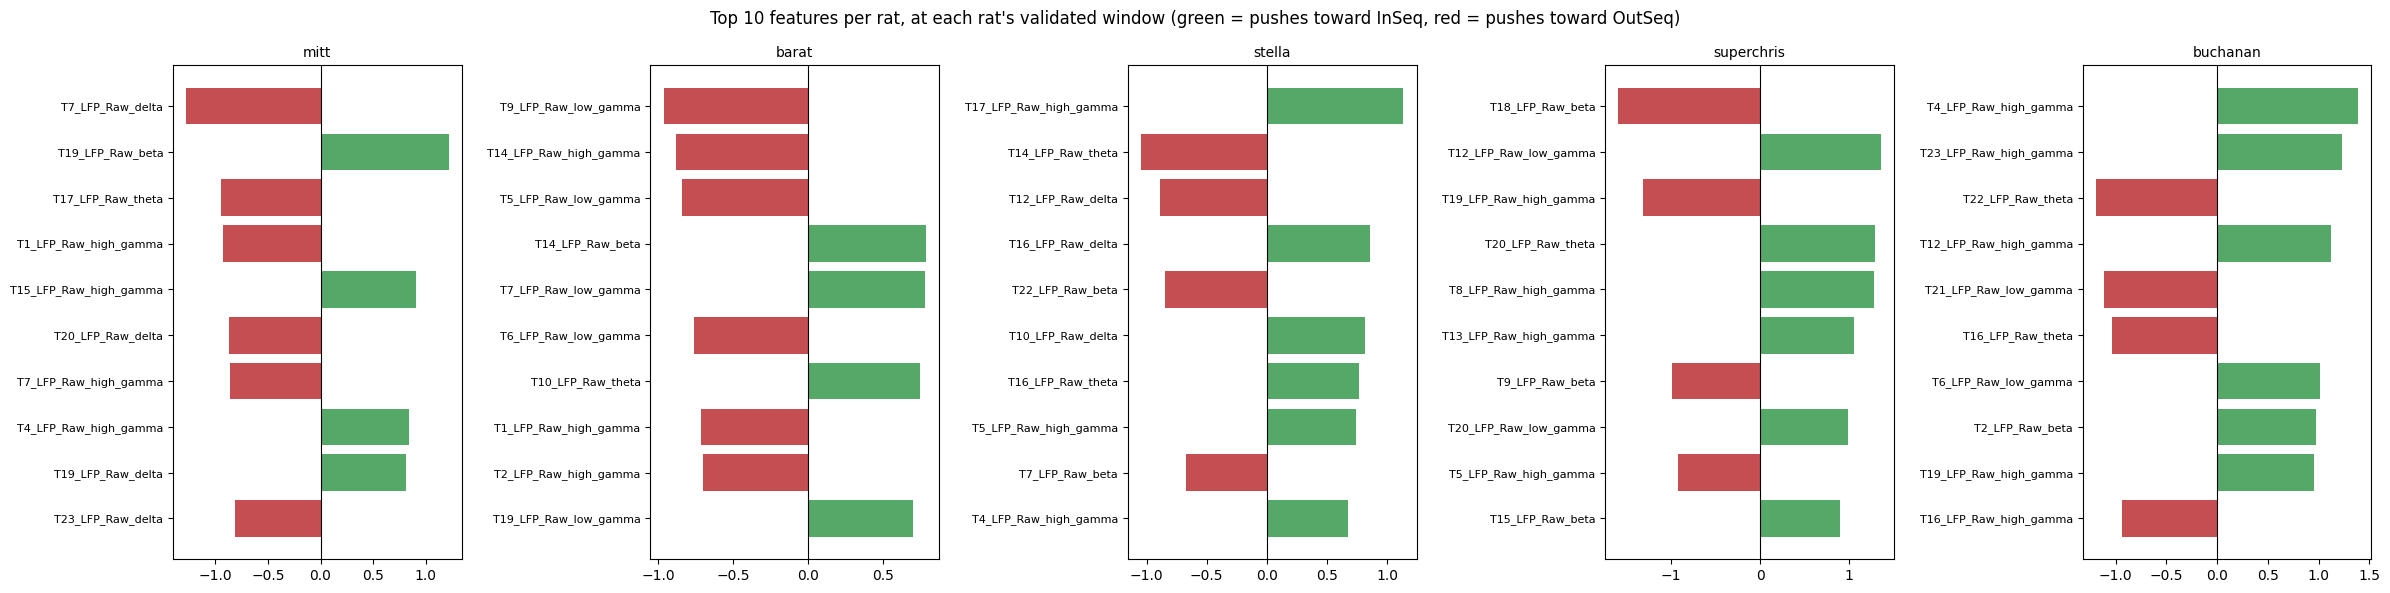

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(24, 6))

for ax, session_name in zip(axes, per_rat_importance):
    r = per_rat_importance[session_name]
    order = np.argsort(np.abs(r['coefs']))[::-1][:10]
    colors = ['#C44E52' if r['coefs'][i] < 0 else '#55A868' for i in order]
    ax.barh(range(len(order)), r['coefs'][order], color=colors)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([r['feature_names'][i] for i in order], fontsize=8)
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(session_name.split('_')[1], fontsize=10)

plt.suptitle('Top 10 features per rat, at each rat\'s validated window (green = pushes toward InSeq, red = pushes toward OutSeq)')
plt.tight_layout()
plt.show()


## 5. Cross-Rat Band Importance Comparison

Averaging |coefficient| across all channels within each band, per rat, this is the key chart for
checking whether theta specifically dominates, as the meeting notes' emphasis on theta would predict, or
whether other bands matter as much or more.


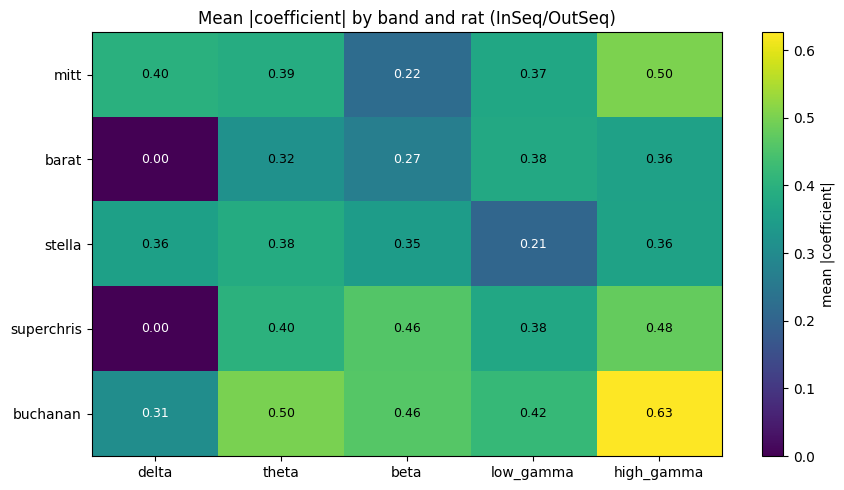

Band importance, averaged across all 5 rats, ranked highest to lowest:
  high_gamma   0.4649
  theta        0.3980
  low_gamma    0.3512
  beta         0.3512
  delta        0.2117


In [6]:
band_importance_matrix = np.zeros((len(per_rat_importance), len(BAND_NAMES)))
session_names = list(per_rat_importance.keys())

for row, session_name in enumerate(session_names):
    r = per_rat_importance[session_name]
    for col, band_name in enumerate(BAND_NAMES):
        band_coefs = [r['coefs'][i] for i, name in enumerate(r['feature_names']) if name.endswith(f'_{band_name}')]
        band_importance_matrix[row, col] = np.mean(np.abs(band_coefs))

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(band_importance_matrix, cmap='viridis', aspect='auto')
ax.set_xticks(range(len(BAND_NAMES)))
ax.set_xticklabels(BAND_NAMES)
ax.set_yticks(range(len(session_names)))
ax.set_yticklabels([s.split('_')[1] for s in session_names])
ax.set_title('Mean |coefficient| by band and rat (InSeq/OutSeq)')
plt.colorbar(im, ax=ax, label='mean |coefficient|')
for i in range(len(session_names)):
    for j in range(len(BAND_NAMES)):
        ax.text(j, i, f'{band_importance_matrix[i, j]:.2f}', ha='center', va='center',
                 color='white' if band_importance_matrix[i, j] < band_importance_matrix.max() / 2 else 'black',
                 fontsize=9)
plt.tight_layout()
plt.show()

overall_band_ranking = band_importance_matrix.mean(axis=0)
ranking_order = np.argsort(overall_band_ranking)[::-1]
print("Band importance, averaged across all 5 rats, ranked highest to lowest:")
for i in ranking_order:
    print(f"  {BAND_NAMES[i]:12s} {overall_band_ranking[i]:.4f}")


## 6. Text-Only Results Export


In [7]:
import json as _json
import os

results_summary = {
    "purpose": "Feature importance for final InSeq/OutSeq models, at each rat's validated window",
    "bands": {name: list(rng) for name, rng in BANDS.items()},
    "band_importance_by_rat": {
        session_names[row]: {BAND_NAMES[col]: round(float(band_importance_matrix[row, col]), 4) for col in range(len(BAND_NAMES))}
        for row in range(len(session_names))
    },
    "overall_band_ranking": [
        {"band": BAND_NAMES[i], "mean_importance": round(float(overall_band_ranking[i]), 4)}
        for i in ranking_order
    ],
    "top_10_features_by_rat": {
        session_name: [
            {"feature": r['feature_names'][i], "coefficient": round(float(r['coefs'][i]), 4)}
            for i in np.argsort(np.abs(r['coefs']))[::-1][:10]
        ]
        for session_name, r in per_rat_importance.items()
    },
}

print(_json.dumps(results_summary, indent=2))

os.makedirs('../outputs/logs', exist_ok=True)
with open('../outputs/logs/notebook015_interpretability_results.json', 'w') as f:
    _json.dump(results_summary, f, indent=2)
print("\nSaved to outputs/logs/notebook015_interpretability_results.json")


{
  "purpose": "Feature importance for final InSeq/OutSeq models, at each rat's validated window",
  "bands": {
    "delta": [
      1,
      4
    ],
    "theta": [
      4,
      12
    ],
    "beta": [
      12,
      30
    ],
    "low_gamma": [
      30,
      80
    ],
    "high_gamma": [
      80,
      150
    ]
  },
  "band_importance_by_rat": {
    "080718_mitt": {
      "delta": 0.3965,
      "theta": 0.3872,
      "beta": 0.2225,
      "low_gamma": 0.3741,
      "high_gamma": 0.502
    },
    "081106_barat": {
      "delta": 0.0,
      "theta": 0.3178,
      "beta": 0.2674,
      "low_gamma": 0.3784,
      "high_gamma": 0.3573
    },
    "090212_stella": {
      "delta": 0.3563,
      "theta": 0.3844,
      "beta": 0.346,
      "low_gamma": 0.2074,
      "high_gamma": 0.3599
    },
    "090212_superchris": {
      "delta": 0.0,
      "theta": 0.4012,
      "beta": 0.4585,
      "low_gamma": 0.3758,
      "high_gamma": 0.4793
    },
    "090420_buchanan": {
      "delta": 0.

## Interpretability Results — Validated Windows, All 5 Rats

**High gamma is the most important band overall** (mean |coefficient| 0.465), ranking above theta
(0.398), low gamma and beta (tied, 0.351), and delta (0.212, see caveat below). This is a notable
finding: high gamma was the band added specifically per advisor feedback, and it turns out to matter
most across the model, a direct validation of that suggestion.

**Theta remains consistently important** (rank #2 across every individual rat, not just on average),
supporting its role as neuroscientifically meaningful for this task, though it is not the single
dominant band the emphasis in earlier meeting notes might suggest.

**No channel is consistently important across rats.** Each rat's top features involve different
electrode numbers (Mitt: T7, T19, T17; Barat: T9, T14, T5; Stella: T17, T14, T12; Superchris: T18, T12,
T19; Buchanan: T4, T23, T22). This is expected given each rat has a physically distinct implant, and is
consistent with the per-rat channel differences already found in the notebook 012 structural audit.

**Caveat: delta band results are not reliable and should not be interpreted.** Barat and Superchris show
exactly 0.0 importance for delta, not just low, but literally zero. This is very likely a methodological
artifact rather than a real finding: the 250ms window used for classification is too short to reliably
resolve frequencies in the 1-4 Hz delta range (a full cycle of a 1 Hz signal takes 1 full second, four
times the window length), so the FFT's frequency resolution lands right at the edge of the delta
boundary. Small differences in exact sample count push some rats' boundary bin just inside delta
(nonzero) and others just outside (exactly zero), a resolution artifact, not a biological difference
between rats. High gamma and theta, by contrast, sit comfortably within this window's resolvable
frequency range and can be trusted.

**Overall:** report high gamma and theta as the two most important, reliable
bands, consistent across all 5 rats. Omit or explicitly caveat any delta-band claims given the window
length limitation. Channel-level importance should be described as rat-specific, not shared across
animals, consistent with each having a distinct electrode implant.